In [54]:
# Import packages
import PKA_Sleep as PKA
from PKA_Sleep import Graphing_Utils as graph
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from natsort import natsorted
graph.make_bigandbold()
from copy import deepcopy
import glob

In [39]:
import importlib
importlib.reload(PKA.memPKA_Dynamics)
importlib.reload(PKA)

<module 'PKA_Sleep' from '/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/__init__.py'>

In [13]:
experiment_names = ['ltFLiPAKARmemEEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0010',
                    'dgFLiPmemAKAREEGEMG0003',
                    'dgFLiPmemAKAREEGEMG0008',
                    'ltFLiPAKARmemEEGEMG0036',
                    'ltFLiPAKARmemEEGEMG0043',
                    'kgFLiPAKAREEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0055',
                    'ltFLiPAKARmemEEGEMG0068',
                    'ltFLiPAKARmemEEGEMG0072',
                    'ltFLiPAKARmemEEGEMG0085',
                    'ltFLiPAKARmemEEGEMG0090-1',
                    'ltFLiPAKARmemEEGEMG0094',
                    'ltFLiPAKARmemEEGEMG0097-1',
                    'ltFLiPAKARmemEEGEMG0098-1',
                    'ltFLiPAKARmemEEGEMG0099-1',
                    'ltFLiPAKARmemEEGEMG0099-2',
                    'ltFLiPAKARmemEEGEMG0100-1',
                    'ltFLiPAKARmemEEGEMG0101-1',
                    'ltFLiPAKARmemEEGEMG0102-1',
                    'ltFLiPAKARmemEEGEMG0103-1',
                    'kgFLiPAKAREEGEMG0018',
                    'kgFLiPAKAREEGEMG0019',
                    'kgFLiPAKAREEGEMG0020']
mouse_names = ['3825',
                '3825',
                '3825',
                '3825',
                '4346-t5-7',
                '4346-t5-7',
                '4507',
                '4502',
                '4507',
                '4610',
                '4713',
                '4769',
                '4775',
                '5782',
                '5007',
                '5075',
                '5075',
                '5078',
                '5046',
                '5047',
                '5076',
                '5582',
                '5583',
                '5577']

In [14]:
##------------------------------------ Baseline Data ---------------------------##
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Working_figs/PKA_Sleep_Project/HazardModel/'

df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [os.path.join(parent_data_directory, e) for e in experiment_names]
baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in experiment_names]]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 3, specific_acqs = False, pull_baseline = True, 
                                          baseline_idxs = baseline_idxs)
# Set FLiP class parameters and build classes
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 200
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = False
seperate_acqs = False
shuffled = True

FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                     exclude_acqs = excluded_acqs)

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_3982/2661696299.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values))


You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this expe

In [91]:
# MA_durations = np.arange(4, 60, 4)
all_haz_mod   = {'Experimental':{}, 'Shuffled':{}}
# all_zt_cats   = {'Experimental':{}, 'Shuffled':{}}
# MA_durations = np.flip(MA_durations)
# fig, ax = plt.subplots(figsize = [12, 5])
# for m in MA_durations:
m = 16
print("="*40+'Brief Arousal Duration = ' + str(m)+"="*40)
sleep_duration_vals = []
pka_sp = []
shuff_pka_sp = []
animal_list = []
event = []
bout_ID = []
MA_count = []
ZT_time = []
bout_num = 0
for b, FLP_exp, a in zip(FLP_classes_dict['Experiment Names'], FLP_classes_dict['Experiment Classes'], 
                         FLP_classes_dict['Animal Names']):
    temp_pka_sp = []
    ss_MA = PKA.define_MAs(deepcopy(FLP_exp.SleepStates), 5, epoch_len = FLP_exp.EpochLength, cutoff_dur = m)
    alt_sleepstates = deepcopy(ss_MA)
    alt_sleepstates[(alt_sleepstates == 5) | (alt_sleepstates == 3)] = 2
    onoff_df = FLP_exp.ss_onset_offset(alt_sleepstates = alt_sleepstates)
    for i in onoff_df.loc[(onoff_df['State'] == 2)].index:
        if i < onoff_df.index.stop-1:
            # if onoff_df['State'].loc[i+1] == 1:
            bout_idx, = np.where((FLP_exp.Time >= onoff_df['Start Time'].loc[i]) & (FLP_exp.Time <= onoff_df['End Time'].loc[i]))
            SS_idx, = np.where((FLP_exp.SSTime >= onoff_df['Start Time'].loc[i]) & (FLP_exp.SSTime < onoff_df['End Time'].loc[i]))
            if any(ss_MA[SS_idx] == 5):
                MA_count_temp = np.zeros(len(bout_idx))
                sleep_states_long = ss_MA[SS_idx][np.searchsorted(FLP_exp.SSTime[SS_idx], FLP_exp.Time[bout_idx], side = 'right')-1]
                find_MAs = PKA.find_continuous(sleep_states_long, [5])
                for MA_num, c in enumerate(find_MAs):
                    MA_count_temp[c[0]:] = MA_num+1
                MA_count.append(MA_count_temp)
            else:
                MA_count.append(np.zeros(len(bout_idx)))
            temp_pka_sp.append(FLP_exp.Lifetime[bout_idx])
            ZT_time.append(FLP_exp.ZeitTime[bout_idx])
            sleep_duration_vals.append(FLP_exp.Time[bout_idx]-FLP_exp.Time[bout_idx][0])
            bout_ID.append(np.full(len(bout_idx), bout_num))
            bout_num = bout_num + 1
            animal_list.append(np.full(len(bout_idx), a))
            temp_event = np.zeros(len(bout_idx))
            temp_event[-1] = 1
            event.append(temp_event)
    if len(temp_pka_sp) == 0:
        continue
    all_values = np.concatenate(temp_pka_sp)
    global_mean = all_values.mean()
    global_std  = all_values.std()
    shuff_vals = PKA.shuffle_singlestate(temp_pka_sp)
    for arr,shuff_arr in zip(temp_pka_sp, shuff_vals):
        pka_sp.append((arr - global_mean) / global_std)
        shuff_pka_sp.append((shuff_arr - global_mean) / global_std)
out = PKA.hazard_model(sleep_duration_vals, pka_sp, animal_list, event, bout_ID, MA_count, ZT_time, run_bootstrap=False, 
                       run_ph_test=False, return_data = True, run_linearity=False,
                R_filename='/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/final_frailty_model_withMAZT_logtime.R')
all_haz_mod['Experimental'][str(m)]= out['res']

out = PKA.hazard_model(sleep_duration_vals, shuff_pka_sp, animal_list, event, bout_ID, MA_count, ZT_time, run_bootstrap=False, 
                       run_ph_test=False, return_data = False, run_linearity=False,
                R_filename='/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/final_frailty_model_withMAZT_logtime.R')
all_haz_mod['Shuffled'][str(m)] = out['res']

========================================Brief Arousal Duration = 16========================================

RUNNING COXME FRAILTY MODELS VIA R
Data loaded:
  Rows     : 899383
  Animals  : 18
  Bouts    : 3227
  ZT range : 0.00 -- 24.00
  log(stop) mean (centering value): 5.0604

Fitting models...
PKA-SP HR at mean time (main)         : 0.8008 [0.7639, 0.8394]  p=2.4841e-20
PKA-SP x log(time) coef (main)        : -0.1250  p=2.5388e-07
PKA-SP HR at mean time (main_wo_zt)   : 0.8172 [0.7803, 0.8559]  p=1.1912e-17
PKA-SP HR at mean time (final)        : 0.8644 [0.8237, 0.9072]  p=3.3773e-09
PKA-SP x log(time) coef (final)       : -0.0972  p=6.4602e-05
PKA-SP HR at mean time (final_wo_zt)  : 0.8799 [0.8391, 0.9228]  p=1.3640e-07
MA HR (MA model)                      : 0.7617 [0.7369, 0.7874]  p=2.7280e-58
MA HR (final model)                   : 0.7986 [0.7715, 0.8266]  p=1.9690e-37
MA HR (final_wo_zt model)             : 0.8093 [0.7823, 0.8372]  p=2.1085e-34
Frailty variance (main)       

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


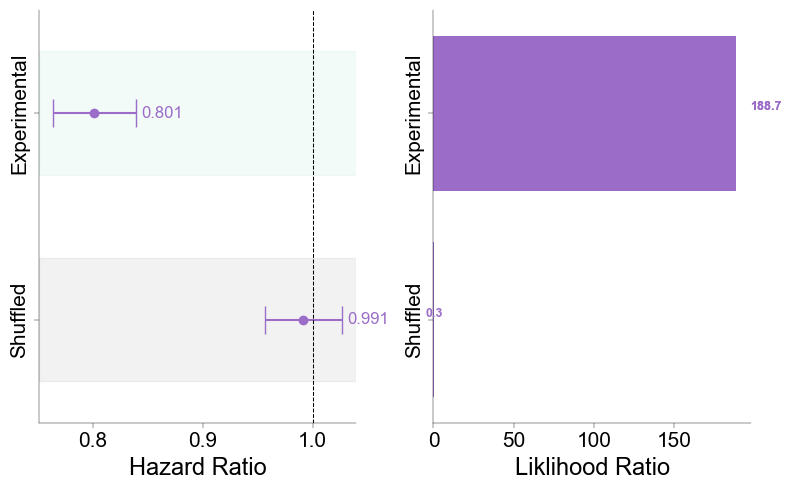

In [56]:
i = '16'
fig, (ax1, ax2) = plt.subplots(figsize = [8, 5], ncols = 2)

ax1.errorbar(all_haz_mod['Experimental'][i]['hr_pka_main'], 1, 
               xerr=[[abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_high'])]],
           color='#9B6CC8', fmt = "o", markersize = 6, capsize = 10)
ax1.text(all_haz_mod['Experimental'][i]['hr_pka_main_high'] + 0.005, 1, f"{all_haz_mod['Experimental'][i]['hr_pka_main']:.3f}",
     va="center", fontsize=12, color='#9B6CC8')


ax1.errorbar(all_haz_mod['Shuffled'][i]['hr_pka_main'], 0, 
               xerr=[[abs(all_haz_mod['Shuffled'][i]['hr_pka_main']-all_haz_mod['Shuffled'][i]['hr_pka_main_low'])], 
                     [abs(all_haz_mod['Shuffled'][i]['hr_pka_main']-all_haz_mod['Shuffled'][i]['hr_pka_main_high'])]],
           color='#9B6CC8', fmt = "o", markersize = 6, capsize = 10)
ax1.text(all_haz_mod['Shuffled'][i]['hr_pka_main_high'] + 0.005, 0, f"{all_haz_mod['Shuffled'][i]['hr_pka_main']:.3f}",
     va="center", fontsize=12, color='#9B6CC8')

ax1.axvline(1, color='k', linestyle="--", lw=0.75)
ax1.axhspan(0.7, 1.3, alpha=0.05, color='#00b47c')
ax1.axhspan(-0.3, 0.3, alpha=0.05, color="k")
ax1.set_ylim(-0.5, 1.5)

ax2.barh(1, all_haz_mod['Experimental'][i]['lr_main_base'], color='#9B6CC8', height = 0.75)
ax2.text(all_haz_mod['Experimental'][i]['lr_main_base'] * 1.1, 1, 
         f"{all_haz_mod['Experimental'][i]['lr_main_base']:.1f}", ha="center", va="bottom", fontsize=9, 
         fontweight="bold", color = '#9B6CC8')
ax2.barh(1, all_haz_mod['Experimental'][i]['lr_main_base'], color='#9B6CC8', height = 0.75)
ax2.text(all_haz_mod['Experimental'][i]['lr_main_base'] * 1.1, 1, 
         f"{all_haz_mod['Experimental'][i]['lr_main_base']:.1f}", ha="center", va="bottom", fontsize=9, 
         fontweight="bold", color = '#9B6CC8')

ax2.barh(0, all_haz_mod['Shuffled'][i]['lr_main_base'], color='#9B6CC8', height = 0.75)
ax2.text(all_haz_mod['Shuffled'][i]['lr_main_base'] * 1.1, 0, 
         f"{all_haz_mod['Shuffled'][i]['lr_main_base']:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color = '#9B6CC8')

graph.thick_axes(fig, [ax1, ax2], width = 0.3)
graph.label_axes(ax1, x = 'Hazard Ratio')
graph.label_axes(ax2, x = 'Liklihood Ratio')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Shuffled', 'Experimental'], rotation = 90, verticalalignment ='center')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Shuffled', 'Experimental'], rotation = 90, verticalalignment ='center')
ax2.set_ylim(ax1.get_ylim())
fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'HazardModel_REMasSleep_16MA.png'))
fig.savefig(os.path.join(fig_savedir, 'HazardModel_REMasSleep_16MA.ps'))

In [102]:
# all_haz_mod = {'Experimental':{}}
perm_dir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Working_figs/PKA_Sleep_Project/HazardModel/'
perm_files = natsorted(glob.glob(os.path.join(perm_dir, 'perm_test_resultsMA*.npy')))
bootstrap_files = glob.glob(os.path.join(perm_dir, 'perm_test_results*.npy'))
bootstrap_files = natsorted([fn for fn in bootstrap_files if 'MA' not in fn])
all_results = pd.DataFrame(columns = ['MA Threshold', 'Bootstrapped Avg Atten','Atten Permutations'])
all_results['MA Threshold'] = np.arange(4, 60, 4)
for b in bootstrap_files:
    bootstrap_dict = np.load(b, allow_pickle=True).item()
    for k in bootstrap_dict['Experimental'].keys():
        this_dict = bootstrap_dict['Experimental'][k]
        all_haz_mod['Experimental'][k] = this_dict
        all_results.loc[all_results['MA Threshold'] == int(k),'Bootstrapped Avg Atten'] = this_dict['atten_pka_boot_mean']
 
for p in perm_files:
    data_dict = np.load(p, allow_pickle=True).item()
    for k in data_dict['Permutations'].keys():
        perm_vals = [data_dict['Permutations'][k][d]['atten_pka'] for d in data_dict['Permutations'][k].keys()]
        try:
            idx = all_results[all_results['MA Threshold'] == int(k)].index[0]
        except IndexError:
            continue
        all_results.at[idx, 'Atten Permutations'] = perm_vals

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


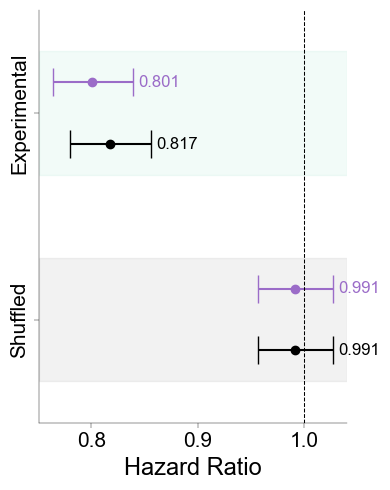

In [58]:
fig, ax1 = plt.subplots(figsize = [4, 5])
offset = 0.15
#Experimental data with and without ZT
ax1.errorbar(all_haz_mod['Experimental'][i]['hr_pka_main'], 1+offset, 
               xerr=[[abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_high'])]],
                color='#9B6CC8', fmt = "o", markersize = 6, capsize = 10)

ax1.text(all_haz_mod['Experimental'][i]['hr_pka_main_high'] + 0.005, 1+offset, f"{all_haz_mod['Experimental'][i]['hr_pka_main']:.3f}",va="center", fontsize=12, color='#9B6CC8')
ax1.errorbar(all_haz_mod['Experimental'][i]['hr_pka_main_wo_zt'], 1-offset, 
               xerr=[[abs(all_haz_mod['Experimental'][i]['hr_pka_main_wo_zt']-all_haz_mod['Experimental'][i]['hr_pka_main_wo_zt_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['hr_pka_main_wo_zt']-all_haz_mod['Experimental'][i]['hr_pka_main_wo_zt_high'])]],
             color='k', fmt = "o", markersize = 6, capsize = 10)
ax1.text(all_haz_mod['Experimental'][i]['hr_pka_main_wo_zt_high'] + 0.005, 1-offset, 
         f"{all_haz_mod['Experimental'][i]['hr_pka_main_wo_zt']:.3f}",va="center", fontsize=12, color='k')


ax1.errorbar(all_haz_mod['Shuffled'][i]['hr_pka_main'], 0-offset, 
               xerr=[[abs(all_haz_mod['Shuffled'][i]['hr_pka_main_wo_zt']-all_haz_mod['Shuffled'][i]['hr_pka_main_wo_zt_low'])], 
                     [abs(all_haz_mod['Shuffled'][i]['hr_pka_main_wo_zt']-all_haz_mod['Shuffled'][i]['hr_pka_main_wo_zt_high'])]],
           color='k', fmt = "o", markersize = 6, capsize = 10)
ax1.text(all_haz_mod['Shuffled'][i]['hr_pka_main_wo_zt_high'] + 0.005, 0-offset, f"{all_haz_mod['Shuffled'][i]['hr_pka_main_wo_zt']:.3f}",
    va="center", fontsize=12, color='k')
ax1.errorbar(all_haz_mod['Shuffled'][i]['hr_pka_main'], 0+offset, 
               xerr=[[abs(all_haz_mod['Shuffled'][i]['hr_pka_main']-all_haz_mod['Shuffled'][i]['hr_pka_main_low'])], 
                     [abs(all_haz_mod['Shuffled'][i]['hr_pka_main']-all_haz_mod['Shuffled'][i]['hr_pka_main_high'])]],
           color='#9B6CC8', fmt = "o", markersize = 6, capsize = 10)
ax1.text(all_haz_mod['Shuffled'][i]['hr_pka_main_high'] + 0.005, 0+offset, f"{all_haz_mod['Shuffled'][i]['hr_pka_main']:.3f}",
     va="center", fontsize=12, color='#9B6CC8')

ax1.axvline(1, color='k', linestyle="--", lw=0.75)
ax1.axhspan(0.7, 1.3, alpha=0.05, color='#00b47c')
ax1.axhspan(-0.3, 0.3, alpha=0.05, color="k")
ax1.set_ylim(-0.5, 1.5)
graph.thick_axes(fig, ax1, width = 0.3)
graph.label_axes(ax1, x = 'Hazard Ratio')
graph.label_axes(ax2, x = 'Liklihood Ratio')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Shuffled', 'Experimental'], rotation = 90, verticalalignment ='center')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Shuffled', 'Experimental'], rotation = 90, verticalalignment ='center')
ax2.set_ylim(ax1.get_ylim())
fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'HazardModel_Atten_REMasSleep_16MA.png'))
fig.savefig(os.path.join(fig_savedir, 'HazardModel_Atten_REMasSleep_16MA.ps'))


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


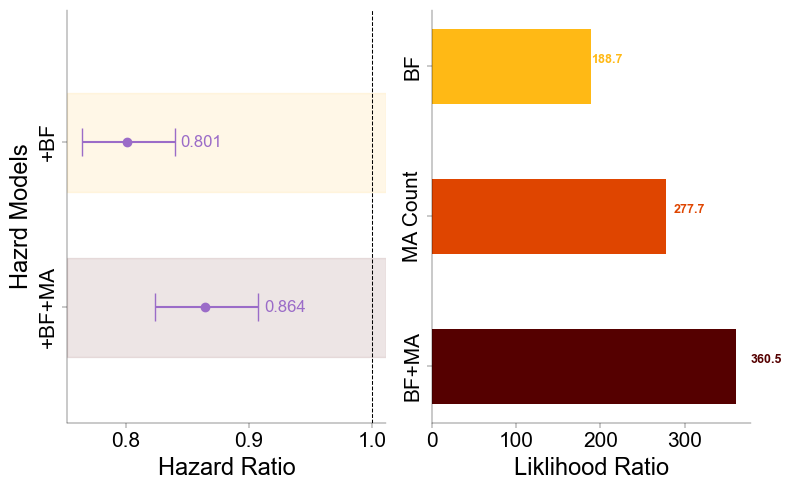

In [59]:
fig, (ax1, ax2) = plt.subplots(figsize = [8, 5], ncols = 2)
offset = 0.2

ax1.errorbar(all_haz_mod['Experimental'][i]['hr_pka_main'], 1+offset, 
               xerr=[[abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_high'])]],
           color='#9B6CC8', fmt = "o", markersize = 6, capsize = 10)
ax1.text(all_haz_mod['Experimental'][i]['hr_pka_main_high'] + 0.005, 1+offset, f"{all_haz_mod['Experimental'][i]['hr_pka_main']:.3f}",
     va="center", fontsize=12, color='#9B6CC8')


ax1.errorbar(all_haz_mod['Experimental'][i]['hr_pka_final'], 0+offset, 
               xerr=[[abs(all_haz_mod['Experimental'][i]['hr_pka_final']-all_haz_mod['Experimental'][i]['hr_pka_final_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['hr_pka_final']-all_haz_mod['Experimental'][i]['hr_pka_final_high'])]],
           color='#9B6CC8', fmt = "o", markersize = 6, capsize = 10)

ax1.text(all_haz_mod['Experimental'][i]['hr_pka_final_high'] + 0.005, 0+offset, f"{all_haz_mod['Experimental'][i]['hr_pka_final']:.3f}",
     va="center", fontsize=12, color='#9B6CC8')
ax1.axvline(1, color='k', linestyle="--", lw=0.75)
ax1.axhspan(0.9, 1.5, alpha=0.1, color='#FFB915')
ax1.axhspan(-0.1, 0.5, alpha=0.1, color="#550000")
ax1.set_ylim(-0.5, 2)

ax2.barh(0, all_haz_mod['Experimental'][i]['lr_final_base'], color='#550000', height = 0.5)
ax2.text(all_haz_mod['Experimental'][i]['lr_final_base'] * 1.1, 0, 
         f"{all_haz_mod['Experimental'][i]['lr_final_base']:.1f}", ha="center", va="bottom", fontsize=9, 
         fontweight="bold", color = '#550000')

ax2.barh(1, all_haz_mod['Experimental'][i]['lr_ma_base'], color='#DF4500', height = 0.5)
ax2.text(all_haz_mod['Experimental'][i]['lr_ma_base'] * 1.1, 1, 
         f"{all_haz_mod['Experimental'][i]['lr_ma_base']:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color = '#DF4500')

ax2.barh(2, all_haz_mod['Experimental'][i]['lr_main_base'], color='#FFB915', height = 0.5)
ax2.text(all_haz_mod['Experimental'][i]['lr_main_base'] * 1.1, 2, 
         f"{all_haz_mod['Experimental'][i]['lr_main_base']:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", 
         color = '#FFB915')


graph.thick_axes(fig, [ax1, ax2], width = 0.3)
graph.label_axes(ax1, x = 'Hazard Ratio', y = 'Hazrd Models')
graph.label_axes(ax2, x = 'Liklihood Ratio')
ax1.set_yticks([0+offset, 1+offset])
ax1.set_yticklabels(['+BF+MA', '+BF'], rotation = 90, verticalalignment ='center')
ax2.set_yticks([0,1,2])
ax2.set_yticklabels(['BF+MA', 'MA Count', 'BF'], rotation = 90, verticalalignment ='center')
fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'Hazard_ModelCompare_REMasSleep_16MA.png'))
fig.savefig(os.path.join(fig_savedir, 'Hazard_ModelCompare_REMasSleep_16MA.ps'))

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_3982/198652948.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(handles = h[:2], labels = l[:2])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


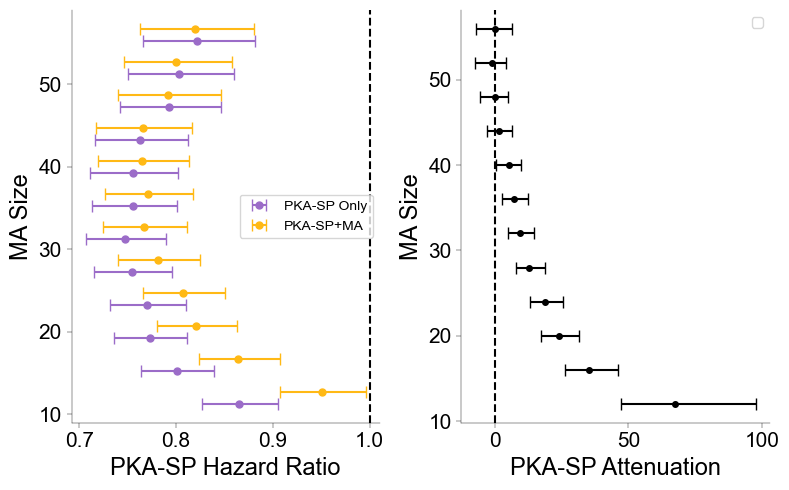

In [104]:
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Working_figs/PKA_Sleep_Project/HazardModel/'
fig, ax = plt.subplots(figsize = [8, 5], ncols = 2)
for h in np.arange(12,60,4):
    i = str(h)
    col1 = 0
    col2 = 1
    bar_height = 2
    y_sep = 0.75

    ax[0].errorbar(all_haz_mod['Experimental'][i]['hr_pka_main'], int(i)-y_sep, 
               xerr=[[abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['hr_pka_main']-all_haz_mod['Experimental'][i]['hr_pka_main_high'])]],
           color='#9B6CC8', fmt = "o", markersize = 5, capsize = 4, label = 'PKA-SP Only')
    
    ax[0].errorbar(all_haz_mod['Experimental'][i]['hr_pka_final'], int(i)+y_sep, 
               xerr=[[abs(all_haz_mod['Experimental'][i]['hr_pka_final']-all_haz_mod['Experimental'][i]['hr_pka_final_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['hr_pka_final']-all_haz_mod['Experimental'][i]['hr_pka_final_high'])]],
           color='#FFB915', fmt = "o", markersize = 5, capsize = 4, label = 'PKA-SP+MA')

    ax[1].errorbar(all_haz_mod['Experimental'][i]['atten_pka_boot_mean'], int(i), 
               xerr=[[abs(all_haz_mod['Experimental'][i]['atten_pka_boot_mean']-all_haz_mod['Experimental'][i]['atten_pka_boot_ci_low'])], 
                     [abs(all_haz_mod['Experimental'][i]['atten_pka_boot_mean']-all_haz_mod['Experimental'][i]['atten_pka_boot_ci_high'])]],
           color='k', fmt = "o", markersize = 4, capsize = 4)

graph.thick_axes(fig, ax, width = 0.3)
ax[0].axvline(1, color = 'k', linestyle = '--')
ax[1].axvline(0, color = 'k', linestyle = '--')

graph.label_axes(ax[0], y = 'MA Size', x = 'PKA-SP Hazard Ratio')
graph.label_axes(ax[1], y = 'MA Size', x = 'PKA-SP Attenuation')
h, l = ax[0].get_legend_handles_labels()
ax[0].legend(handles = h[:2], labels = l[:2])

h, l = ax[1].get_legend_handles_labels()
ax[1].legend(handles = h[:2], labels = l[:2])
# ax[1].set_xlim([-100,100])
fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'CummulativeMA_Model_withZT_REMasSleep.ps'))

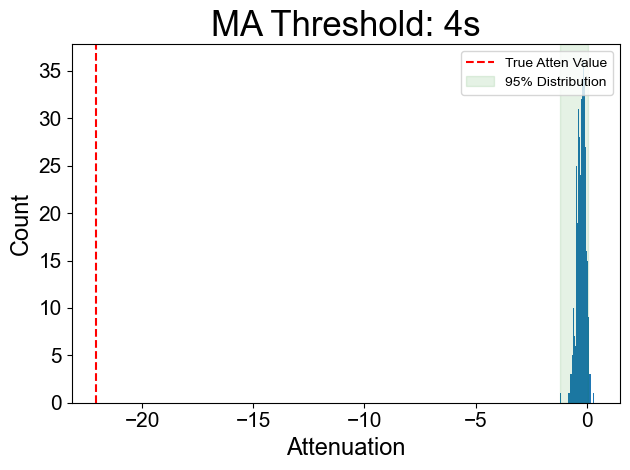

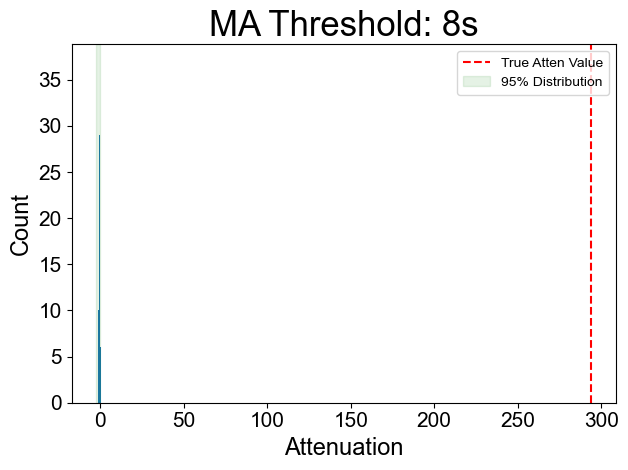

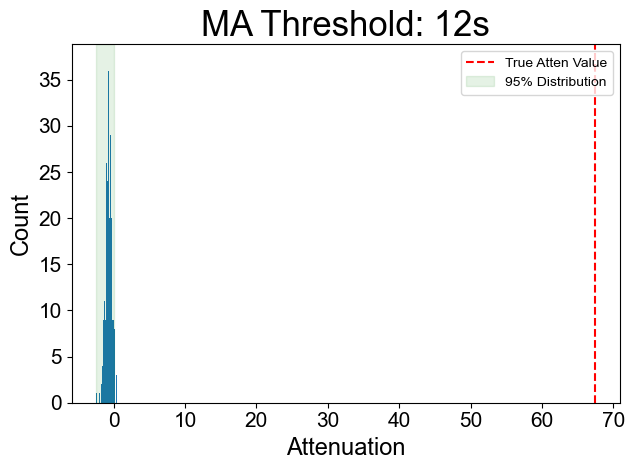

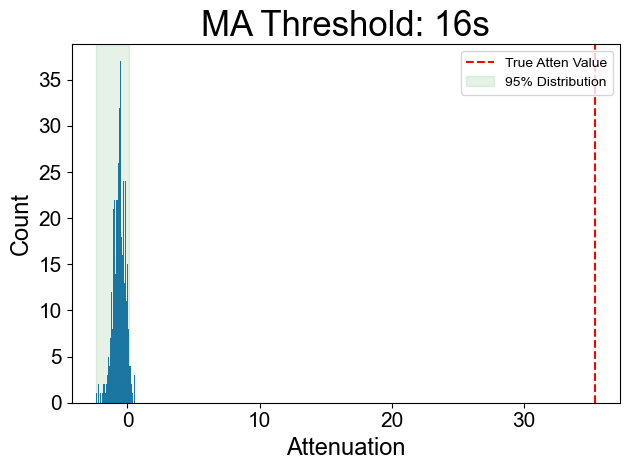

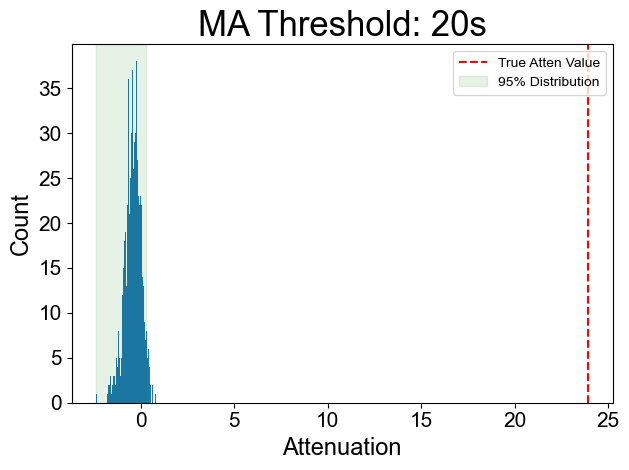

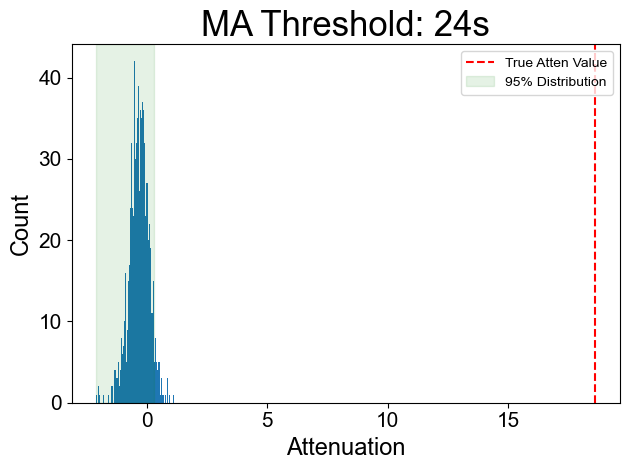

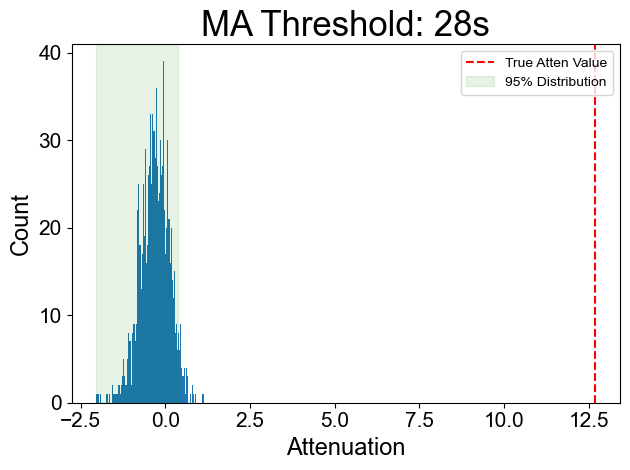

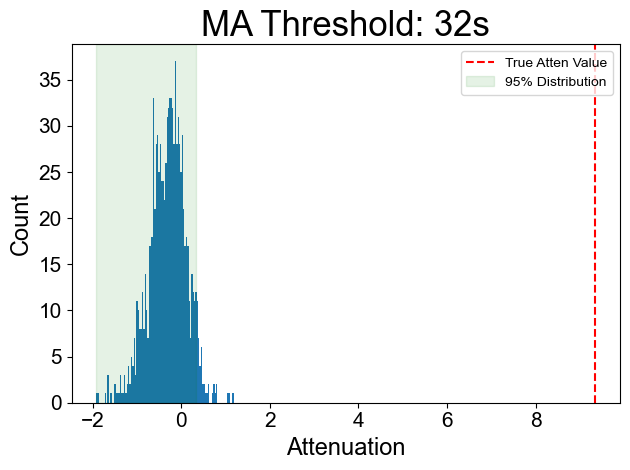

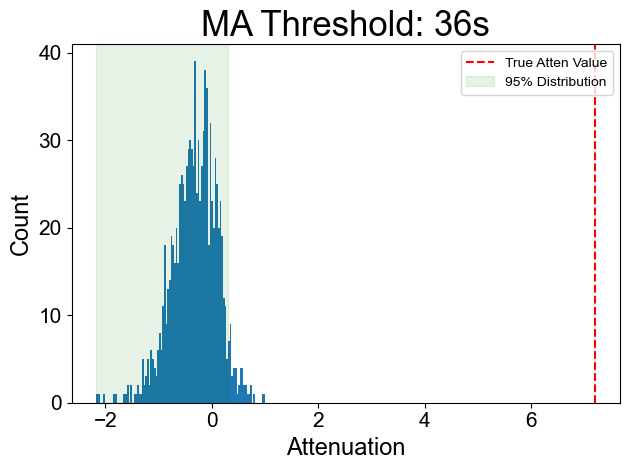

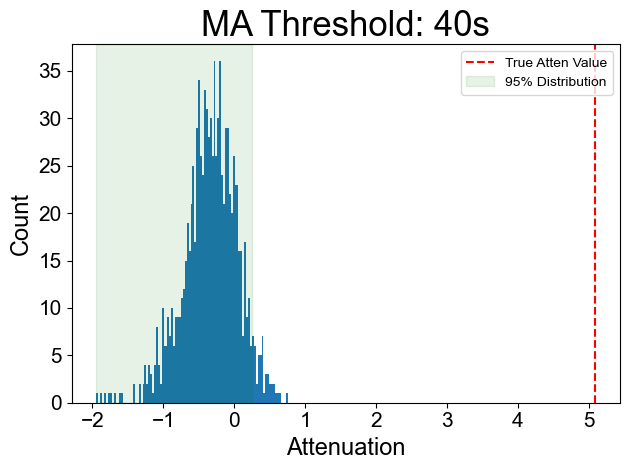

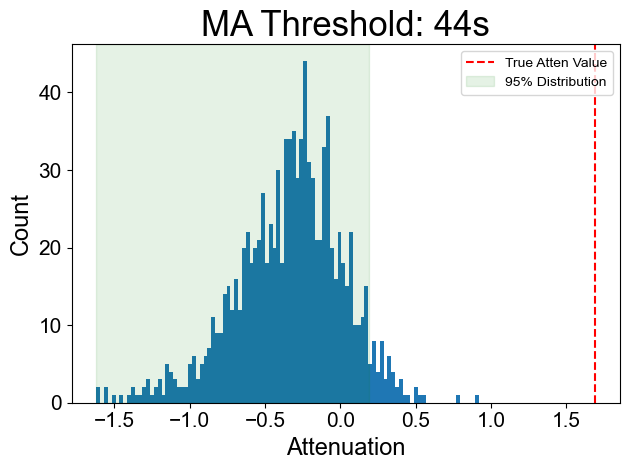

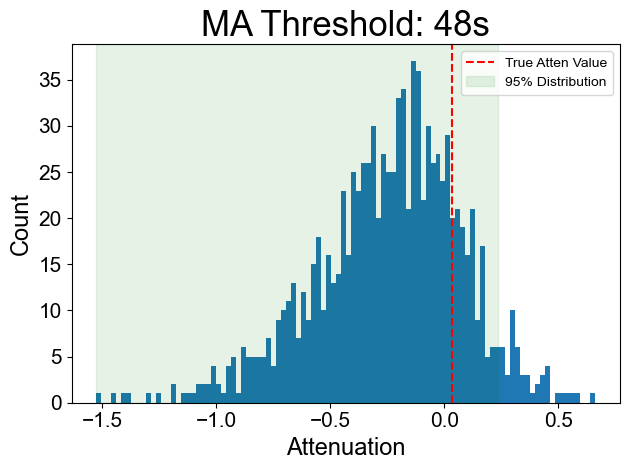

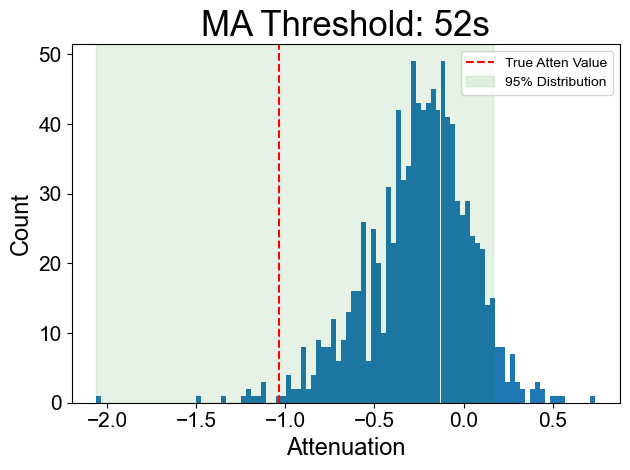

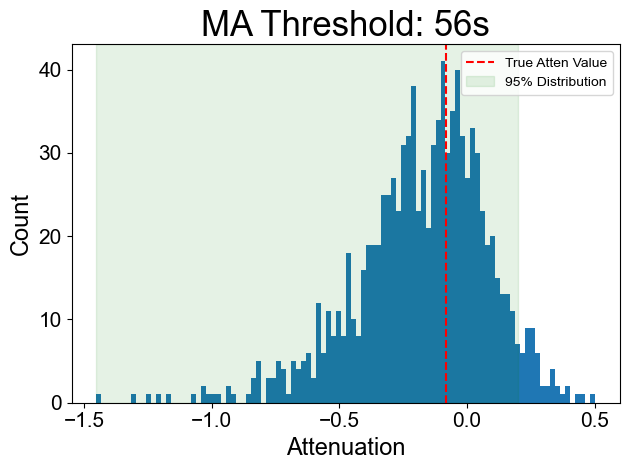

In [89]:
plot_flag = 1
for idx, row in all_results.iterrows():
    fig, ax = plt.subplots()
    try:
        ax.hist(row['Atten Permutations'], bins = 100)
    except ValueError:
        continue
    if plot_flag:    
        ax.axvline(row['Bootstrapped Avg Atten'], color = 'r', linestyle = '--', label = 'True Atten Value')
        ax.axvspan(np.percentile(row['Atten Permutations'], 0), np.percentile(row['Atten Permutations'], 95), color = 'g', alpha = 0.1,
                  label = '95% Distribution')
        graph.label_axes(ax, title = 'MA Threshold: '+ str(row['MA Threshold']) + 's', x = 'Attenuation', y = 'Count')
        ax.legend(loc='upper right')
        fig.tight_layout()
        fig.savefig(os.path.join(perm_dir, 'perm_dist_MA'+str(row['MA Threshold'])+'.png'))
    all_results.loc[idx,'p-val'] = len(np.where(np.asarray(row['Atten Permutations']) > row['Bootstrapped Avg Atten'])[0])/len(row['Atten Permutations'])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


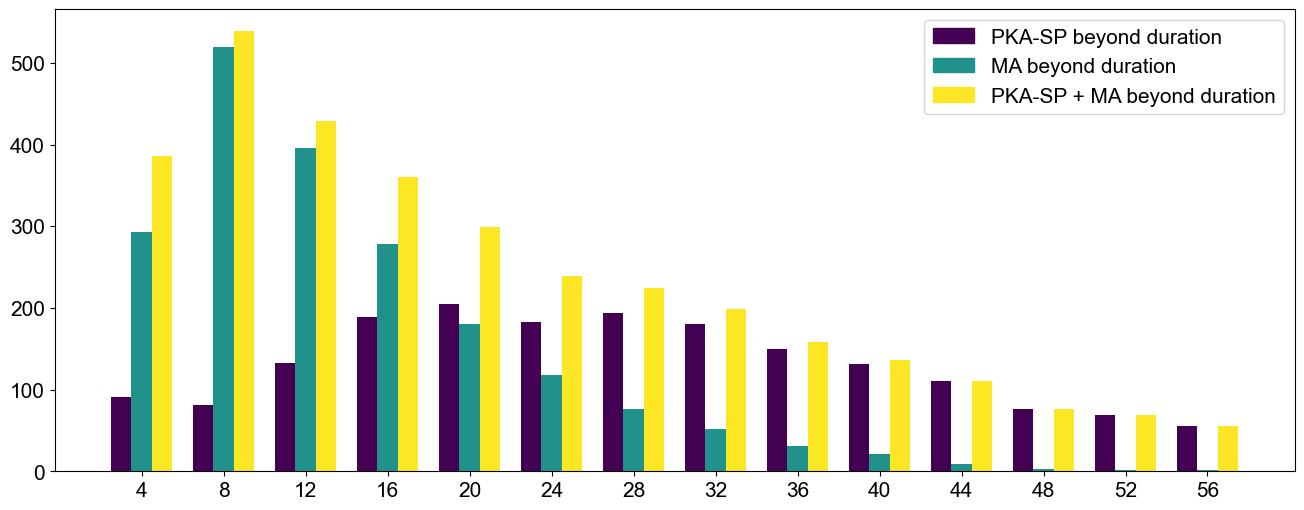

In [45]:
legend_dict = {'lr_main_base': 'PKA-SP beyond duration', 
               'lr_ma_base': 'MA beyond duration', 
               'lr_final_base': 'PKA-SP + MA beyond duration'}
fig = plt.figure(figsize = [16,6])
ax = plt.subplot2grid(shape=(1,1), loc=(0, 0), colspan=1, rowspan = 1)
# lr_keys = [k for k in all_haz_mod['Experimental'][list(all_haz_mod['Experimental'].keys())[0]].keys() if 'lr' in k]
lr_keys = list(legend_dict.keys())
yvals = [[all_haz_mod['Experimental'][str(i)][k] for k in lr_keys] for i in np.arange(4,60,4)]
colors = graph.get_colormap(len(yvals[0]))
graph.grouped_bargraph(fig, ax, yvals, colors, x_labels=np.arange(4,60,4), legend_labels=[legend_dict[k] for k in lr_keys], 
                       edgecolor=None, linewidth=None, rotation=0)
fig.savefig(os.path.join(fig_savedir, 'Likelihood_Ratio_allmods.ps'))

# 